# SQL Sales Analysis

## Objective
Analyze sales and profitability using SQL queries on retail data.

## Tools
- SQLite
- SQL
- Python (Pandas)

## Data Loading

In [11]:
import sqlite3
import pandas as pd

df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")

## Database Creation

In [12]:
conn = sqlite3.connect("superstore.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

9994

## Sales by Category

In [14]:
query = """
-- Sales by category
SELECT Category, SUM(Sales) AS total_sales
FROM sales
GROUP BY Category
ORDER BY total_sales DESC;
"""
df_sales = pd.read_sql(query, conn)
df_sales

,Category,total_sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


<Axes: title={'center': 'Sales by Category'}, xlabel='Category'>

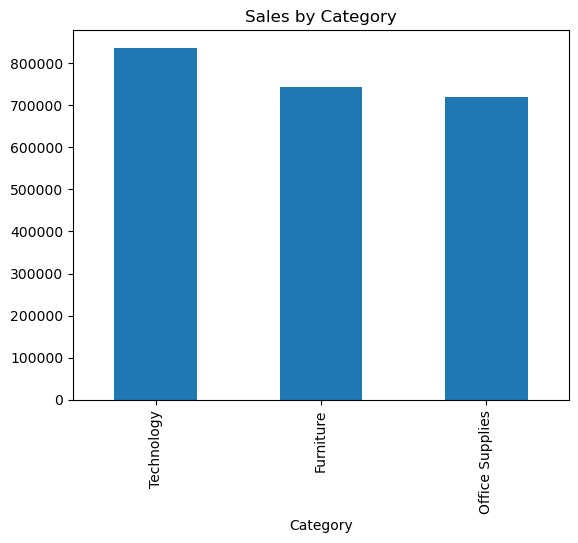

In [6]:
sales_by_category.plot(
    kind="bar",
    x="Category",
    y="total_sales",
    title="Sales by Category",
    legend=False
)

Insight:
Technology generates the highest sales, indicating strong demand and higher revenue potential.

## Profit by Region

In [15]:
query = """
-- Profit by region
SELECT Region, SUM(Profit) AS total_profit
FROM sales
GROUP BY Region
ORDER BY total_profit DESC;
"""
df_profit = pd.read_sql(query, conn)
df_profit

,Region,total_profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


<Axes: title={'center': 'Profit by Region'}, xlabel='Region'>

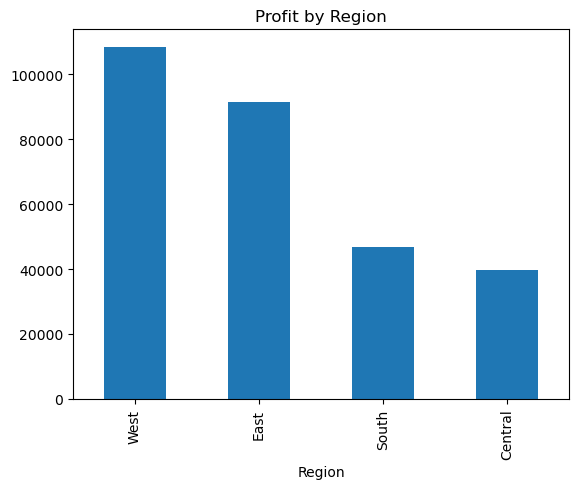

In [7]:
profit_by_region.plot(
    kind="bar",
    x="Region",
    y="total_profit",
    title="Profit by Region",
    legend=False
)

Insight:
Profitability varies across regions, suggesting differences in cost structure or market performance.

## Loss-Making Sub-Categories

In [16]:
query = """
-- Sub-categories with negative profit
SELECT "Sub-Category", SUM(Profit) AS total_profit
FROM sales
GROUP BY "Sub-Category"
HAVING total_profit < 0
ORDER BY total_profit;
"""
df_loss = pd.read_sql(query, conn)
df_loss

,Sub-Category,total_profit
0,Tables,-17725.4811
1,Bookcases,-3472.5560
2,Supplies,-1189.0995


Insight:
Some sub-categories generate losses despite sales, indicating pricing or cost issues.

## Key Findings

- Technology is the top-performing category
- Some sub-categories are loss-making
- Profitability differs across regions

## Business Recommendations

- Focus on high-performing categories
- Investigate loss-making products
- Optimize regional strategies

In [17]:
conn.close()